In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [47]:
df = pd.read_csv('air_passengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')   # MS = month-start, matches the actual timestamps
print('Missing values after asfreq:', df['#Passengers'].isna().sum())
df.head()

Missing values after asfreq: 0


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [48]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [49]:
Q1 = df['#Passengers'].quantile(0.25)
Q3 = df['#Passengers'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['#Passengers'] < lower_bound) | (df['#Passengers'] > upper_bound)]
outliers

,#Passengers
Month,


KeyError: 'Month'

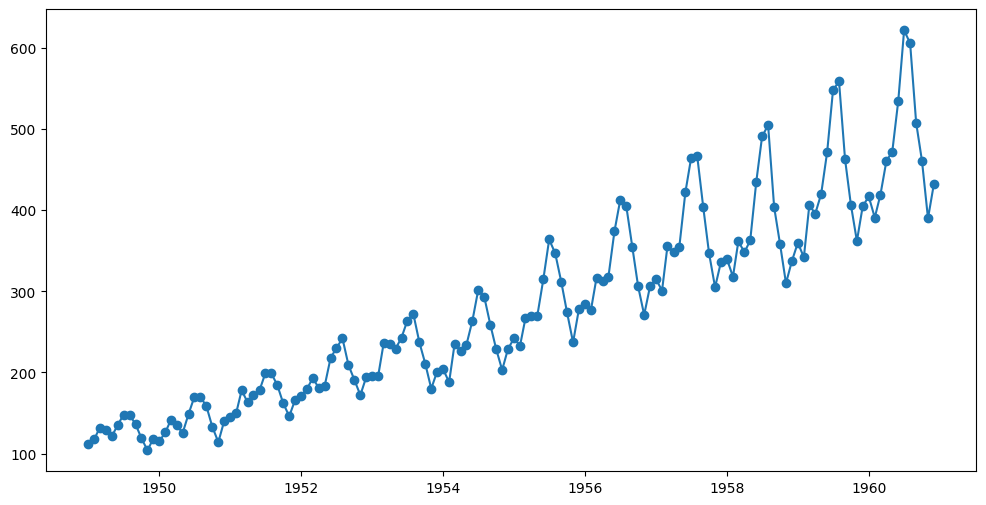

In [51]:
# Plot full dataset
plt.figure(figsize=(12,6))
plt.plot(df.index, df['#Passengers'], marker='o', label='Passengers')

# Highlight anomalies in red
plt.scatter(outliers['Month'], outliers['#Passengers'], color='red', label='Anomalies', zorder=5)

plt.title("Air Passengers Over Time with Anomalies")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

## Stationarity check (ADF test)

In [52]:
result = adfuller(df['#Passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('=> Non-stationary (p > 0.05): trend/seasonality present, as expected.')

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
=> Non-stationary (p > 0.05): trend/seasonality present, as expected.


## Seasonal decomposition

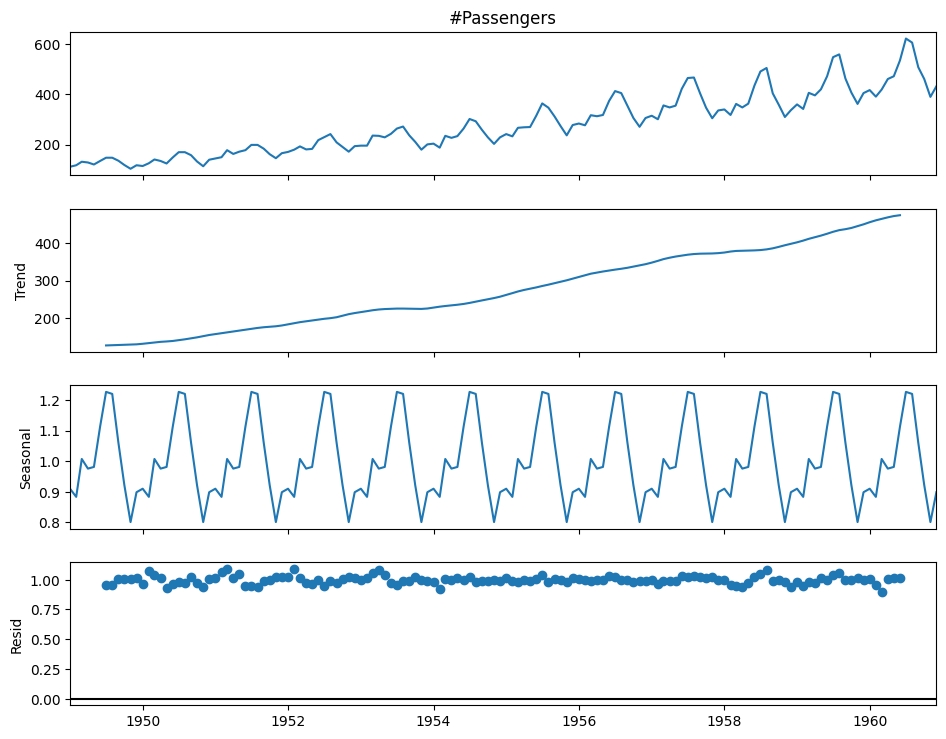

In [53]:
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative', period=12)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

## ACF / PACF

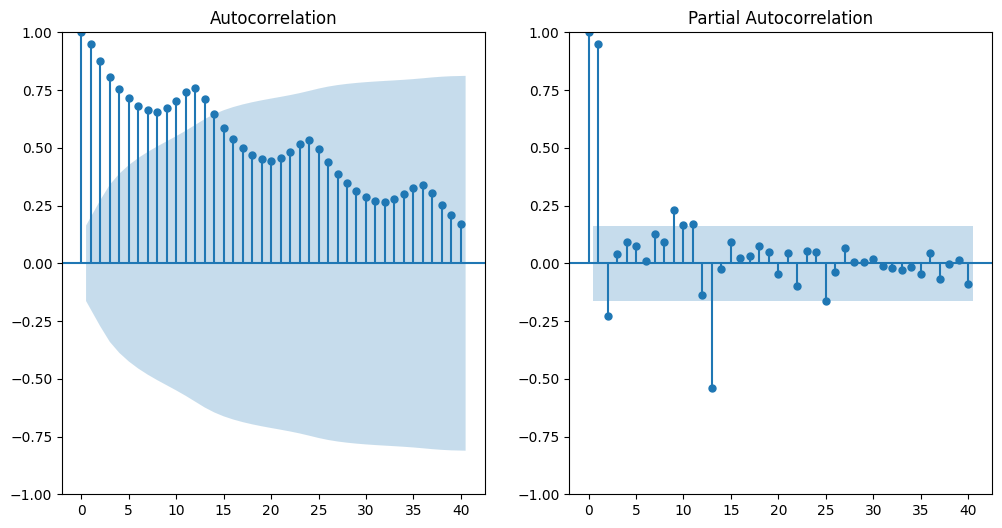

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_acf(df['#Passengers'], lags=40, ax=axes[0])
plot_pacf(df['#Passengers'], lags=40, ax=axes[1])
plt.show()

## Differencing to achieve stationarity

In [55]:
# First difference
df_diff = df['#Passengers'].diff().dropna()

# ADF test on differenced series
result = adfuller(df_diff)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


In [56]:
#Seasonal Differencing
df_seasonal_diff = df['#Passengers'].diff(12).dropna()

result = adfuller(df_seasonal_diff)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.383020726492481
p-value: 0.011551493085514954


## Train/test split

Hold out the last 12 months as a test set.

In [57]:
train = df.iloc[:-12]
test = df.iloc[-12:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} obs)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} obs)")

Train: 1949-01-01 to 1959-12-01 (132 obs)
Test:  1960-01-01 to 1960-12-01 (12 obs)


## SARIMA model

`enforce_stationarity=False` / `enforce_invertibility=False` avoid convergence issues on this short series.

In [58]:
sarima_model = SARIMAX(
    train['#Passengers'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(12)

sarima_rmse = np.sqrt(mean_squared_error(test['#Passengers'], sarima_pred))
sarima_mape = mean_absolute_percentage_error(test['#Passengers'], sarima_pred)
print(f"SARIMA -> RMSE: {sarima_rmse:.2f}, MAPE: {sarima_mape:.2%}")

SARIMA -> RMSE: 21.62, MAPE: 3.76%


## Holt-Winters (Exponential Smoothing)


In [59]:
configs = [
    ('add', 'add'),
    ('add', 'mul'),
    ('mul', 'add'),
    ('mul', 'mul'),
]

hw_results = {}
hw_fits = {}

for trend, seasonal in configs:
    model = ExponentialSmoothing(
        train['#Passengers'],
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=12,
    )
    fit = model.fit()
    pred = fit.forecast(12)

    rmse = np.sqrt(mean_squared_error(test['#Passengers'], pred))
    mape = mean_absolute_percentage_error(test['#Passengers'], pred)

    hw_results[(trend, seasonal)] = (rmse, mape)
    hw_fits[(trend, seasonal)] = (fit, pred)

for config, (rmse, mape) in hw_results.items():
    print(f"Trend={config[0]:>3}, Season={config[1]:>3} -> RMSE: {rmse:7.2f}, MAPE: {mape:.2%}")

Trend=add, Season=add -> RMSE:   16.98, MAPE: 2.80%
Trend=add, Season=mul -> RMSE:   15.81, MAPE: 2.21%
Trend=mul, Season=add -> RMSE:   18.38, MAPE: 3.02%
Trend=mul, Season=mul -> RMSE:   25.81, MAPE: 4.33%


## Compare all models and pick the best

In [61]:
best_hw_config = min(hw_results, key=lambda k: hw_results[k][0])
best_hw_fit, best_hw_pred = hw_fits[best_hw_config]
best_hw_rmse, best_hw_mape = hw_results[best_hw_config]

print(f"Best Holt-Winters config: trend={best_hw_config[0]}, seasonal={best_hw_config[1]}")
print(f"  RMSE: {best_hw_rmse:.2f}, MAPE: {best_hw_mape:.2%}")
print(f"SARIMA(1,1,1)(1,1,1,12)")
print(f"  RMSE: {sarima_rmse:.2f}, MAPE: {sarima_mape:.2%}")

winner = "Holt-Winters" if best_hw_rmse < sarima_rmse else "SARIMA"
print(f"\n=> {winner} performs better on this test set (lower RMSE).")


Best Holt-Winters config: trend=add, seasonal=mul
  RMSE: 15.81, MAPE: 2.21%
SARIMA(1,1,1)(1,1,1,12)
  RMSE: 21.62, MAPE: 3.76%

=> Holt-Winters performs better on this test set (lower RMSE).


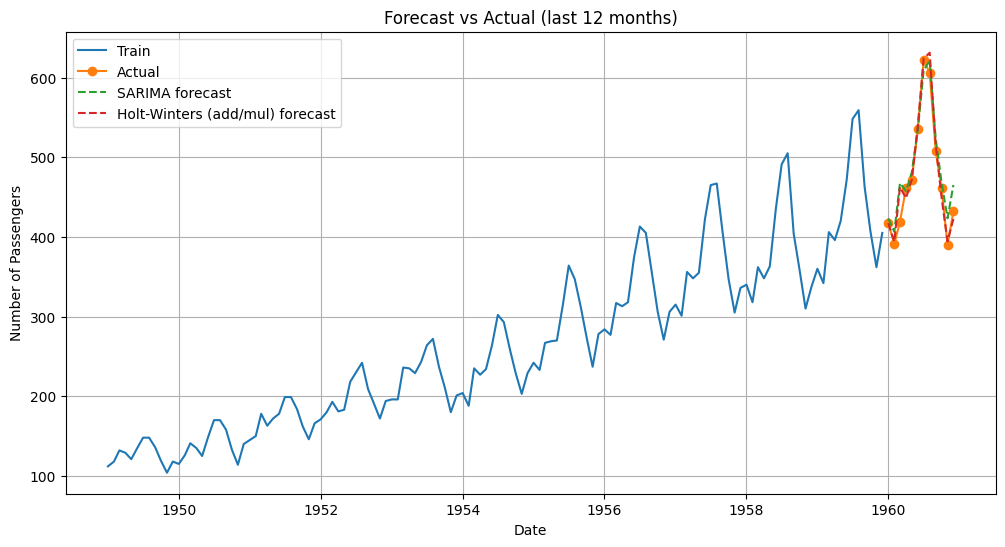

In [62]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['#Passengers'], label='Train')
plt.plot(test.index, test['#Passengers'], label='Actual', marker='o')
plt.plot(test.index, sarima_pred, label='SARIMA forecast', linestyle='--')
plt.plot(test.index, best_hw_pred, label=f'Holt-Winters ({best_hw_config[0]}/{best_hw_config[1]}) forecast', linestyle='--')
plt.title("Forecast vs Actual (last 12 months)")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

## Future Forecast

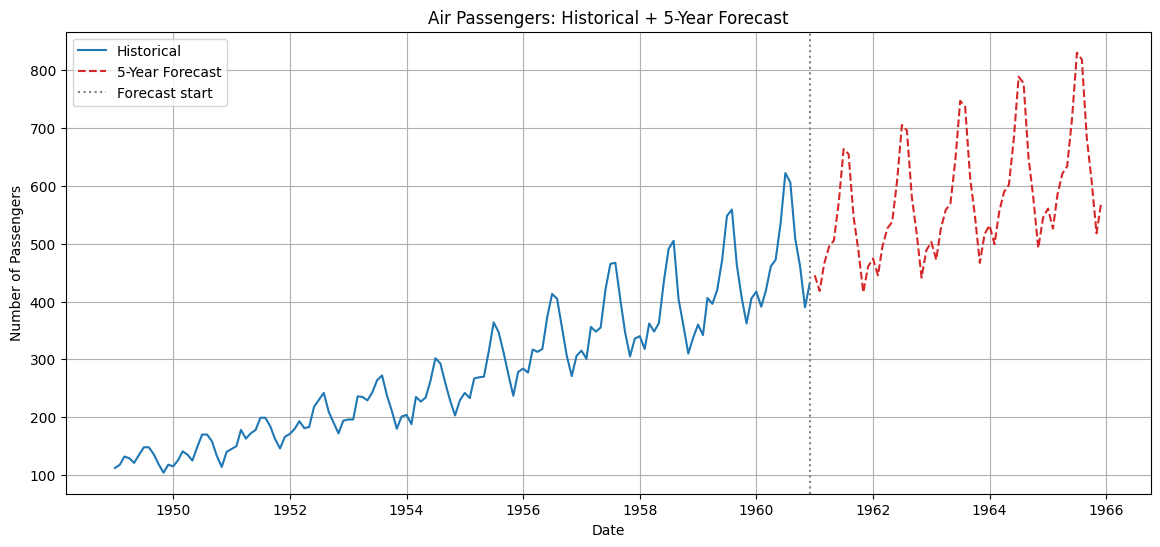

1961    6132.326608
1962    6517.873223
1963    6903.419837
1964    7288.966452
1965    7674.513067
dtype: float64


In [64]:
# Refit the best model (Holt-Winters, additive trend + multiplicative seasonal) on ALL data
final_model = ExponentialSmoothing(
    df['#Passengers'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
)
final_fit = final_model.fit()

FORECAST_MONTHS = 60  # 5 years
future_forecast = final_fit.forecast(FORECAST_MONTHS)

future_index = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS,
    freq='MS'
)
future_forecast.index = future_index

# Plot
plt.figure(figsize=(14,6))
plt.plot(df.index, df['#Passengers'], label='Historical', color='tab:blue')
plt.plot(future_forecast.index, future_forecast, label='5-Year Forecast', color='tab:red', linestyle='--')
plt.axvline(df.index[-1], color='gray', linestyle=':', label='Forecast start')
plt.title("Air Passengers: Historical + 5-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

# Yearly totals sanity check
forecast_yearly = future_forecast.groupby(future_forecast.index.year).sum()
print(forecast_yearly)


In [65]:
hist_yearly = df['#Passengers'].groupby(df.index.year).sum()
combined = pd.concat([hist_yearly.tail(1), forecast_yearly])
yoy_growth = combined.pct_change() * 100
print(yoy_growth.round(1).astype(str) + '%')

1960     NaN
1961    7.3%
1962    6.3%
1963    5.9%
1964    5.6%
1965    5.3%
dtype: str
